# FDA Drug Adverse Event Severity Predictor
## Notebook 1: Exploratory Data Analysis (EDA)

**Goal:** Understand the structure, quality, and patterns in the FDA FAERS dataset before building a predictive model.

**Business Question:** Can we predict whether a drug adverse event will result in a serious outcome (hospitalization, life-threatening reaction, or death) based on patient demographics, drug information, and reaction data?

**Dataset:** FDA Adverse Event Reporting System (FAERS) — 528,000 reports, 2015–2026  
**Source:** Kaggle / openFDA

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load the Dataset

In [3]:
# Update the path below if your file is in a different location
df = pd.read_csv('fda_adverse_events_2015_2026_CLEAN.csv', low_memory=False)

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 528,000 rows x 30 columns


,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


---
## 3. Basic Info & Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528000 entries, 0 to 527999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   report_id            528000 non-null  int64  
 1   receive_date         528000 non-null  object 
 2   year                 528000 non-null  int64  
 3   month                528000 non-null  int64  
 4   quarter              528000 non-null  object 
 5   serious              528000 non-null  object 
 6   serious_flags        226894 non-null  object 
 7   is_fatal             528000 non-null  bool   
 8   is_hospitalized      528000 non-null  bool   
 9   is_life_threat       528000 non-null  bool   
 10  is_disabling         528000 non-null  bool   
 11  reactions            528000 non-null  object 
 12  primary_reaction     528000 non-null  object 
 13  reaction_outcomes    528000 non-null  object 
 14  patient_recovered    528000 non-null  bool   
 15  num_reactions    

In [7]:
df.dtypes

report_id                int64
receive_date            object
year                     int64
month                    int64
quarter                 object
serious                 object
serious_flags           object
is_fatal                  bool
is_hospitalized           bool
is_life_threat            bool
is_disabling              bool
reactions               object
primary_reaction        object
reaction_outcomes       object
patient_recovered         bool
num_reactions            int64
suspect_drug            object
brand_name              object
drug_route              object
drug_indication         object
manufacturer            object
pharm_class             object
num_drugs                int64
drug_count_category     object
patient_age_years      float64
age_group               object
patient_sex             object
patient_weight_kg      float64
country                 object
report_age_days          int64
dtype: object

---
## 4. Missing Values Analysis

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('Columns with missing values:')
missing_df[missing_df['Missing Count'] > 0]

Columns with missing values:


,Missing Count,Missing %
patient_weight_kg,379923,71.96
serious_flags,301106,57.03
patient_age_years,151509,28.69


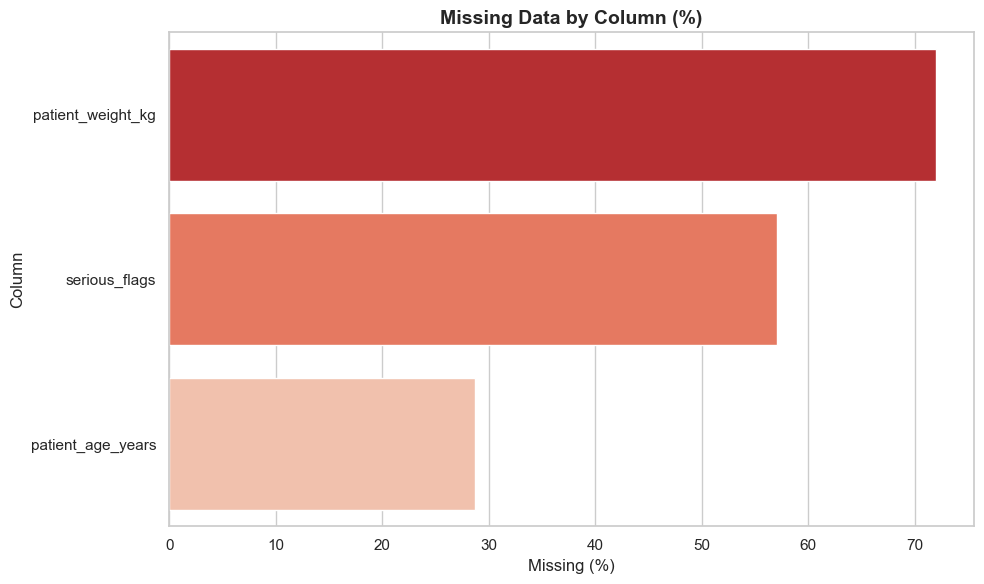

In [11]:
# Visualize missing data
missing_plot = missing_df[missing_df['Missing %'] > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_plot['Missing %'], y=missing_plot.index, palette='Reds_r')
plt.title('Missing Data by Column (%)', fontsize=14, fontweight='bold')
plt.xlabel('Missing (%)')
plt.ylabel('Column')
plt.tight_layout()
plt.savefig('missing_data.png', dpi=150)
plt.show()

---
## 5. Target Variable: `serious`

This is what we are trying to predict whether the adverse event was reported as serious (Yes/No).

In [14]:
print('Value counts for `serious`:')
print(df['serious'].value_counts())
print()
print('Distribution (%):')
print(df['serious'].value_counts(normalize=True).mul(100).round(2))

Value counts for `serious`:
serious
Yes    395000
No     133000
Name: count, dtype: int64

Distribution (%):
serious
Yes    74.81
No     25.19
Name: proportion, dtype: float64


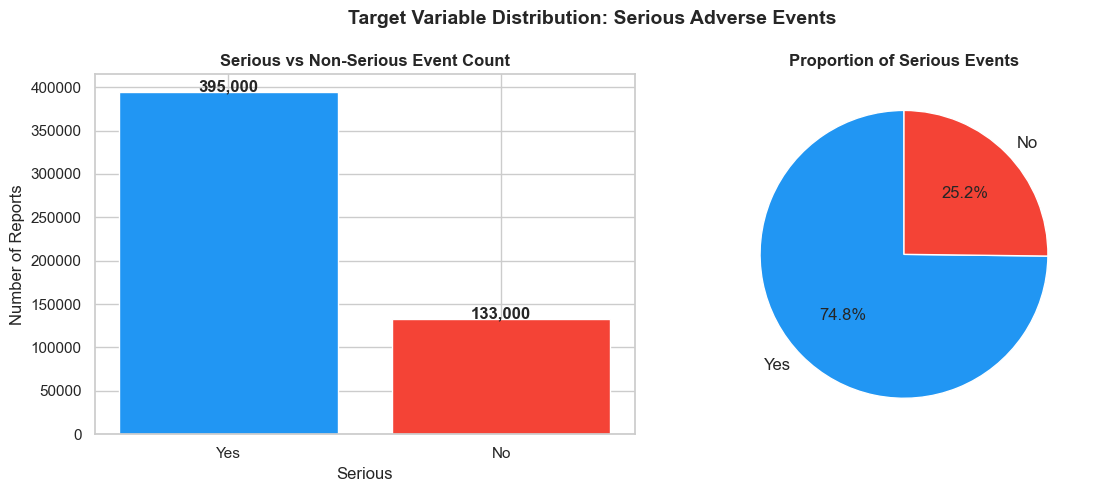

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['serious'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2196F3', '#F44336'])
axes[0].set_title('Serious vs Non-Serious Event Count', fontweight='bold')
axes[0].set_xlabel('Serious')
axes[0].set_ylabel('Number of Reports')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proportion of Serious Events', fontweight='bold')

plt.suptitle('Target Variable Distribution: Serious Adverse Events', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

---
## 6. Outcome Breakdown

Let's understand the breakdown of serious outcome types: fatal, hospitalized, life-threatening, disabling.

In [18]:
outcome_cols = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']

outcome_counts = df[outcome_cols].sum().sort_values(ascending=False)
outcome_pct = (outcome_counts / len(df) * 100).round(2)

print('Outcome breakdown (count and % of all reports):')
pd.DataFrame({'Count': outcome_counts, 'Percent': outcome_pct})

Outcome breakdown (count and % of all reports):


,Count,Percent
is_hospitalized,188042,35.61
is_fatal,54301,10.28
is_life_threat,22871,4.33
is_disabling,13524,2.56


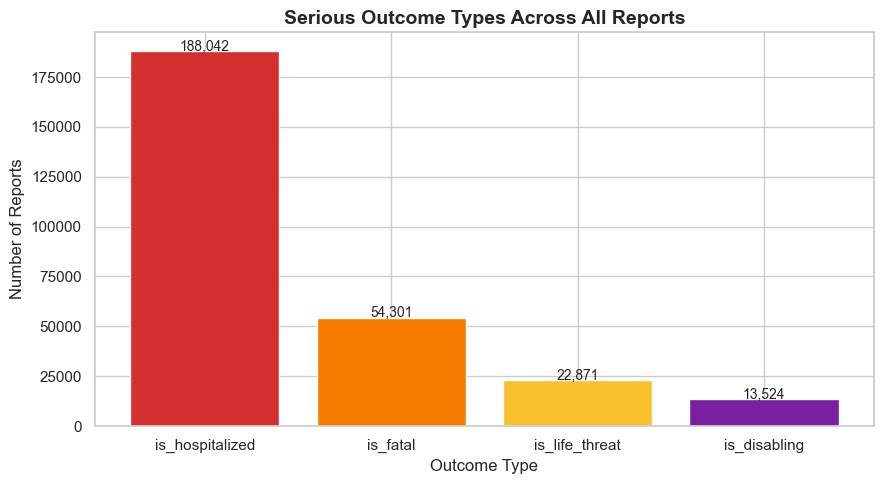

In [20]:
plt.figure(figsize=(9, 5))
colors = ['#D32F2F', '#F57C00', '#FBC02D', '#7B1FA2']
bars = plt.bar(outcome_counts.index, outcome_counts.values, color=colors)
plt.title('Serious Outcome Types Across All Reports', fontsize=14, fontweight='bold')
plt.ylabel('Number of Reports')
plt.xlabel('Outcome Type')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{int(bar.get_height()):,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('outcome_types.png', dpi=150)
plt.show()

---
## 7. Patient Demographics

In [22]:
# Patient Sex distribution
print('Patient Sex distribution:')
print(df['patient_sex'].value_counts())

Patient Sex distribution:
patient_sex
Female     279155
Male       198932
Unknown     49913
Name: count, dtype: int64


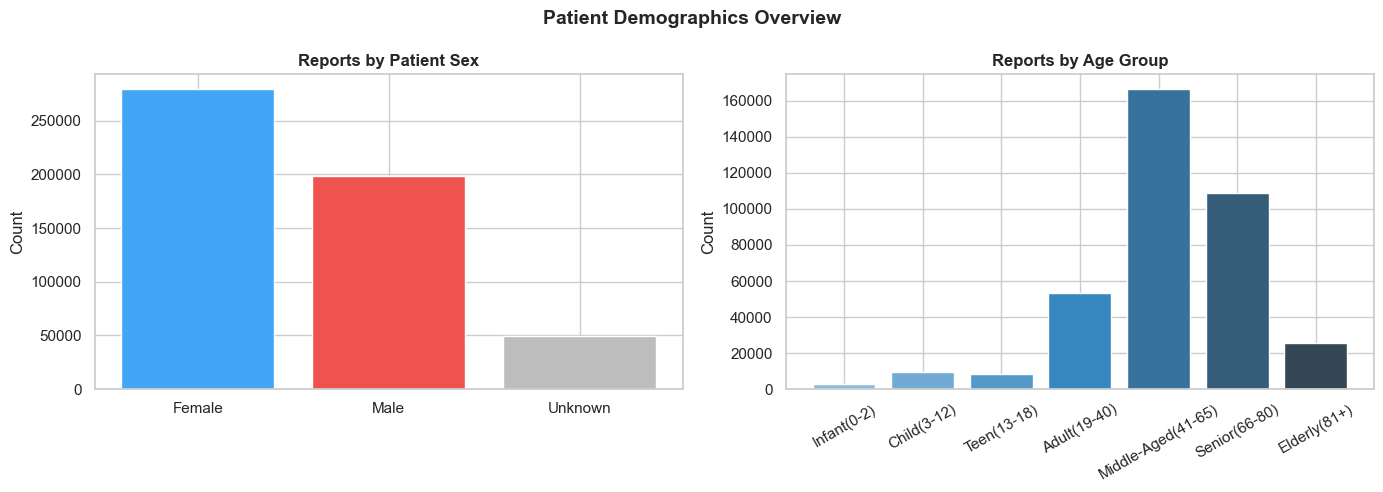

In [30]:
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)', 'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
age_counts = df['age_group'].value_counts().reindex(age_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_counts = df['patient_sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=['#42A5F5', '#EF5350', '#BDBDBD'])
axes[0].set_title('Reports by Patient Sex', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(age_counts.index, age_counts.values, color=sns.color_palette('Blues_d', len(age_counts)))
axes[1].set_title('Reports by Age Group', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Patient Demographics Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('demographics.png', dpi=150)
plt.show()

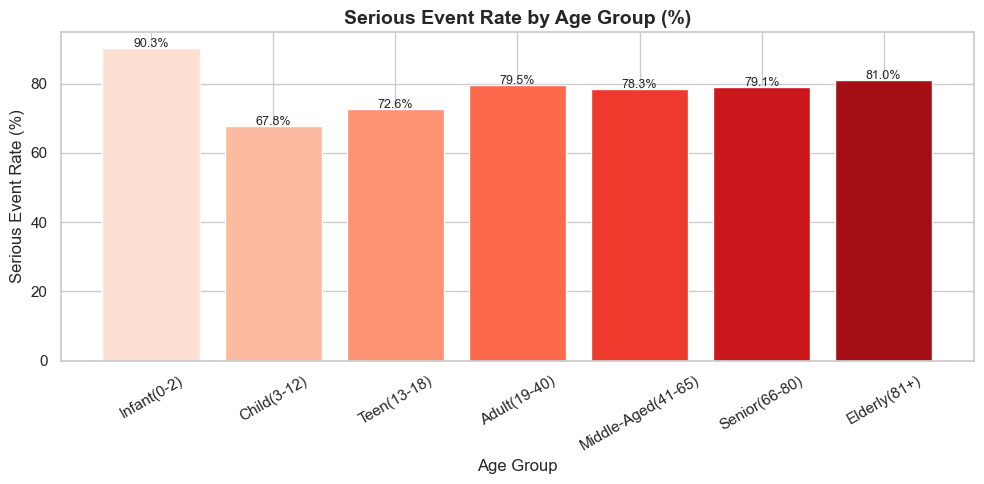

In [32]:
df['serious_binary'] = df['serious'].map({'Yes': 1, 'No': 0})

age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)', 'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
serious_by_age = df.groupby('age_group')['serious_binary'].mean().mul(100).round(2)
serious_by_age = serious_by_age.reindex(age_order).dropna()

plt.figure(figsize=(10, 5))
bars = plt.bar(serious_by_age.index, serious_by_age.values,
               color=sns.color_palette('Reds', len(serious_by_age)))
plt.title('Serious Event Rate by Age Group (%)', fontsize=14, fontweight='bold')
plt.ylabel('Serious Event Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=30)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('serious_by_age.png', dpi=150)
plt.show()

---
## 8. Top Drugs by Adverse Event Reports

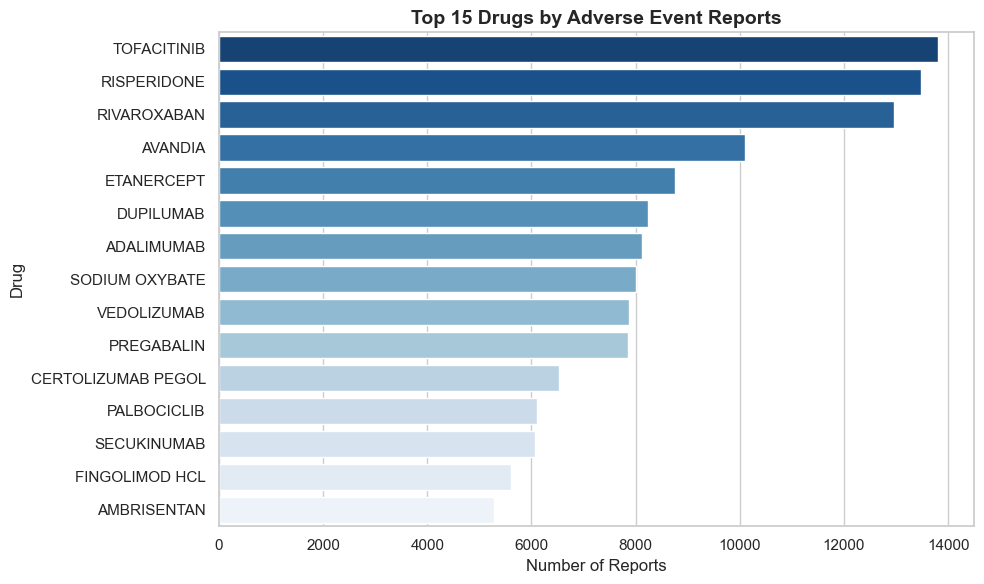

In [34]:
top_drugs = df['suspect_drug'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_drugs.values, y=top_drugs.index, palette='Blues_r')
plt.title('Top 15 Drugs by Adverse Event Reports', fontsize=14, fontweight='bold')
plt.xlabel('Number of Reports')
plt.ylabel('Drug')
plt.tight_layout()
plt.savefig('top_drugs.png', dpi=150)
plt.show()

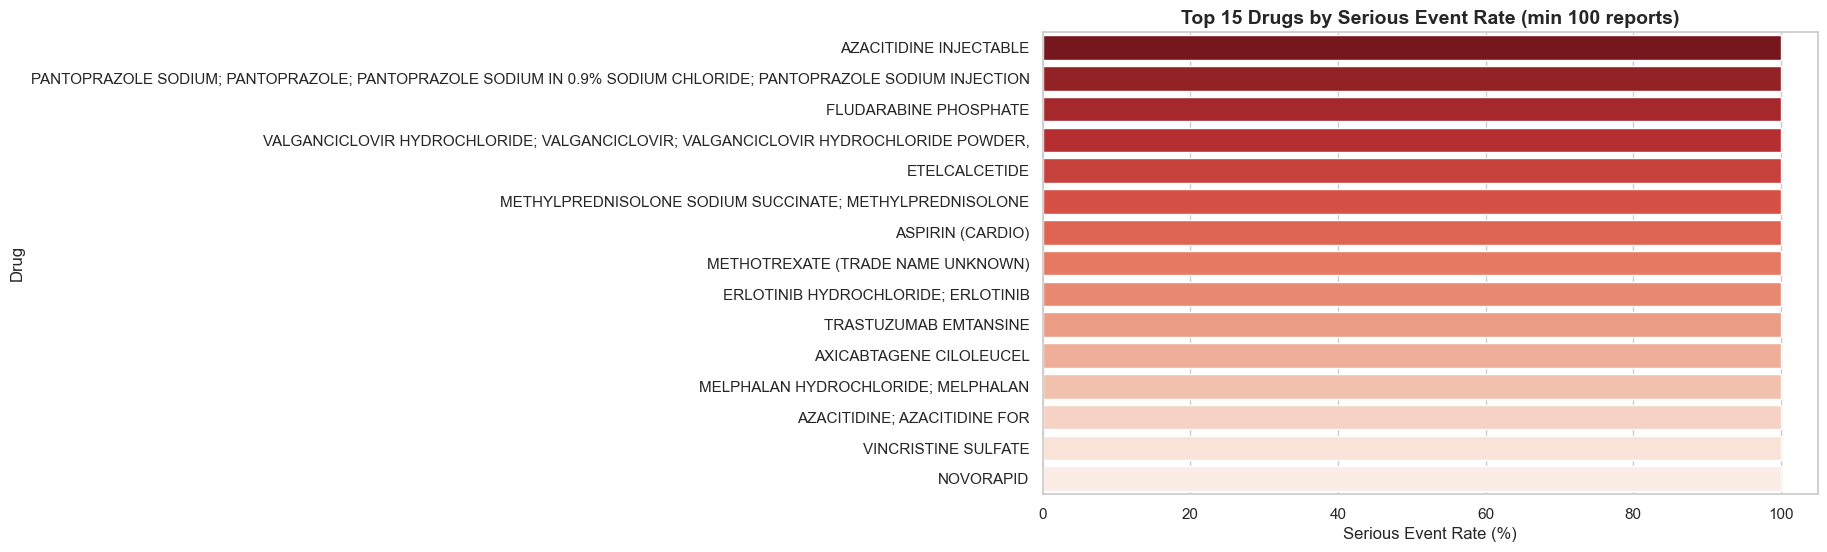

In [36]:
# Which drugs have the highest serious event rate? (min 100 reports to be meaningful)
drug_serious = df.groupby('suspect_drug').agg(
    total=('serious_binary', 'count'),
    serious_rate=('serious_binary', 'mean')
).query('total >= 100').sort_values('serious_rate', ascending=False).head(15)

drug_serious['serious_rate_pct'] = (drug_serious['serious_rate'] * 100).round(2)

plt.figure(figsize=(10, 6))
sns.barplot(x=drug_serious['serious_rate_pct'], y=drug_serious.index, palette='Reds_r')
plt.title('Top 15 Drugs by Serious Event Rate (min 100 reports)', fontsize=14, fontweight='bold')
plt.xlabel('Serious Event Rate (%)')
plt.ylabel('Drug')
plt.tight_layout()
plt.savefig('drugs_serious_rate.png', dpi=150)
plt.show()

---
## 9. Drug Route & Polypharmacy

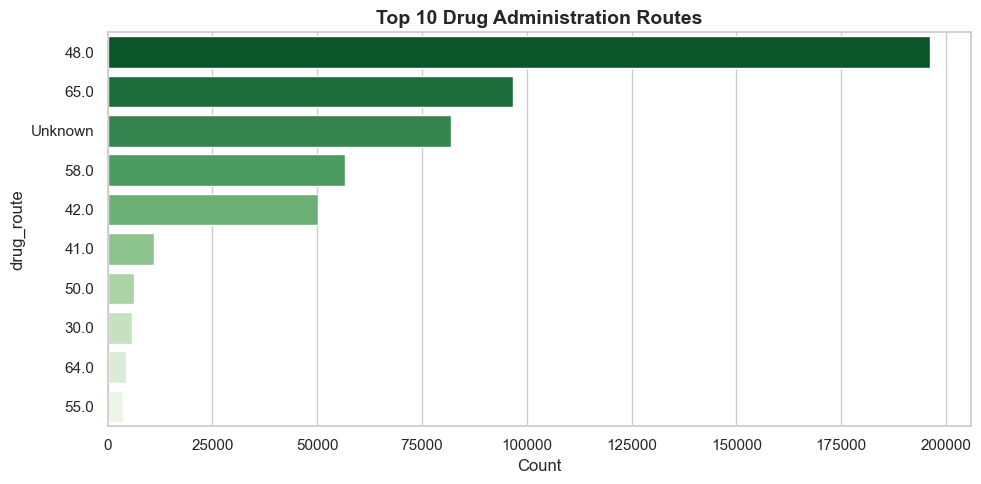

In [38]:
# Top drug routes
top_routes = df['drug_route'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_routes.values, y=top_routes.index, palette='Greens_r')
plt.title('Top 10 Drug Administration Routes', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('drug_routes.png', dpi=150)
plt.show()

In [40]:
# Polypharmacy: does taking more drugs increase serious event rate?
poly_serious = df.groupby('drug_count_category')['serious_binary'].mean().mul(100).round(2)
print('Serious event rate by drug count category:')
print(poly_serious.sort_values(ascending=False))

Serious event rate by drug count category:
drug_count_category
Unknown             99.78
Polypharmacy(6+)    85.70
4-5 Drugs           77.60
2-3 Drugs           67.25
Single              58.81
Name: serious_binary, dtype: float64


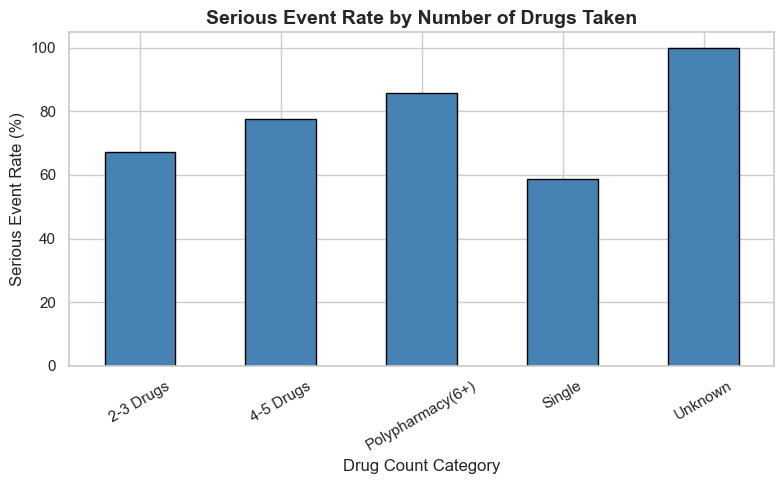

In [42]:
plt.figure(figsize=(8, 5))
poly_serious.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Serious Event Rate by Number of Drugs Taken', fontsize=14, fontweight='bold')
plt.ylabel('Serious Event Rate (%)')
plt.xlabel('Drug Count Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('polypharmacy.png', dpi=150)
plt.show()

---
## 10. Trends Over Time

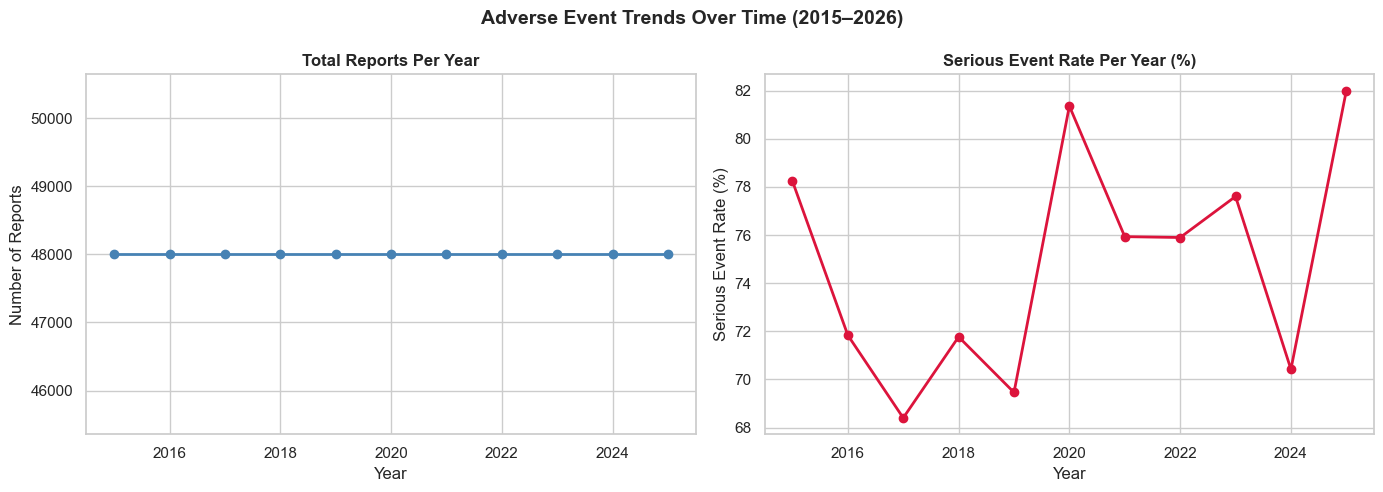

In [44]:
yearly = df.groupby('year').agg(
    total_reports=('report_id', 'count'),
    serious_rate=('serious_binary', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly['year'], yearly['total_reports'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Total Reports Per Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Reports')

axes[1].plot(yearly['year'], yearly['serious_rate'] * 100, marker='o', color='crimson', linewidth=2)
axes[1].set_title('Serious Event Rate Per Year (%)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Serious Event Rate (%)')

plt.suptitle('Adverse Event Trends Over Time (2015–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('trends_over_time.png', dpi=150)
plt.show()

---
## 11. Numeric Feature Distributions

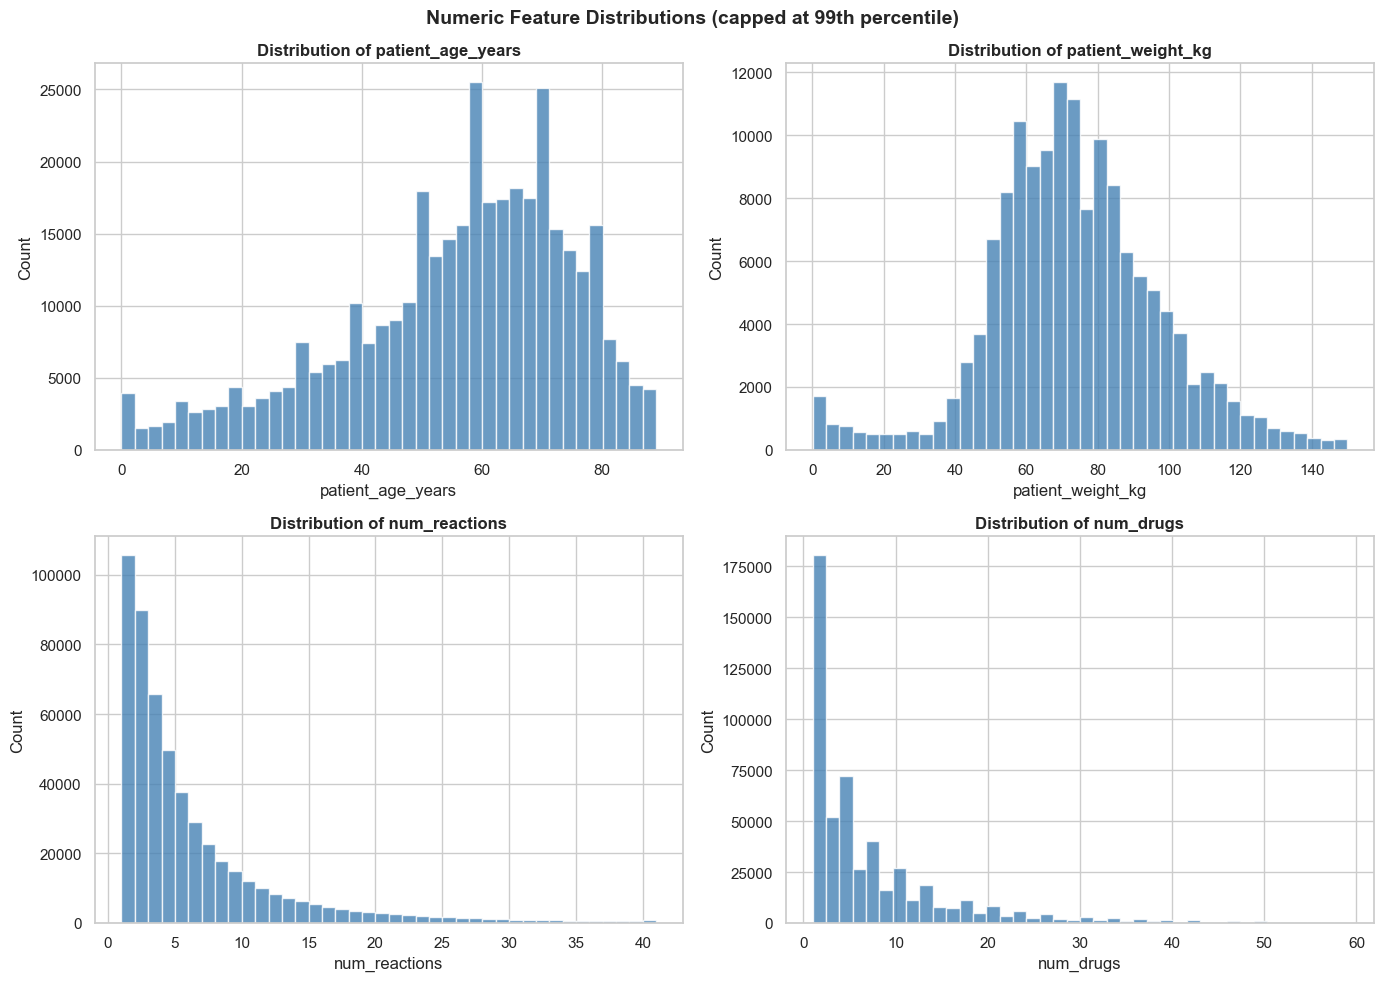

In [46]:
numeric_cols = ['patient_age_years', 'patient_weight_kg', 'num_reactions', 'num_drugs']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col in df.columns:
        data = df[col].dropna()
        # Cap extreme outliers at 99th percentile for better visualization
        cap = data.quantile(0.99)
        data = data[data <= cap]
        axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_title(f'Distribution of {col}', fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions (capped at 99th percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150)
plt.show()

---
## 12. Correlation Heatmap (Numeric Features)

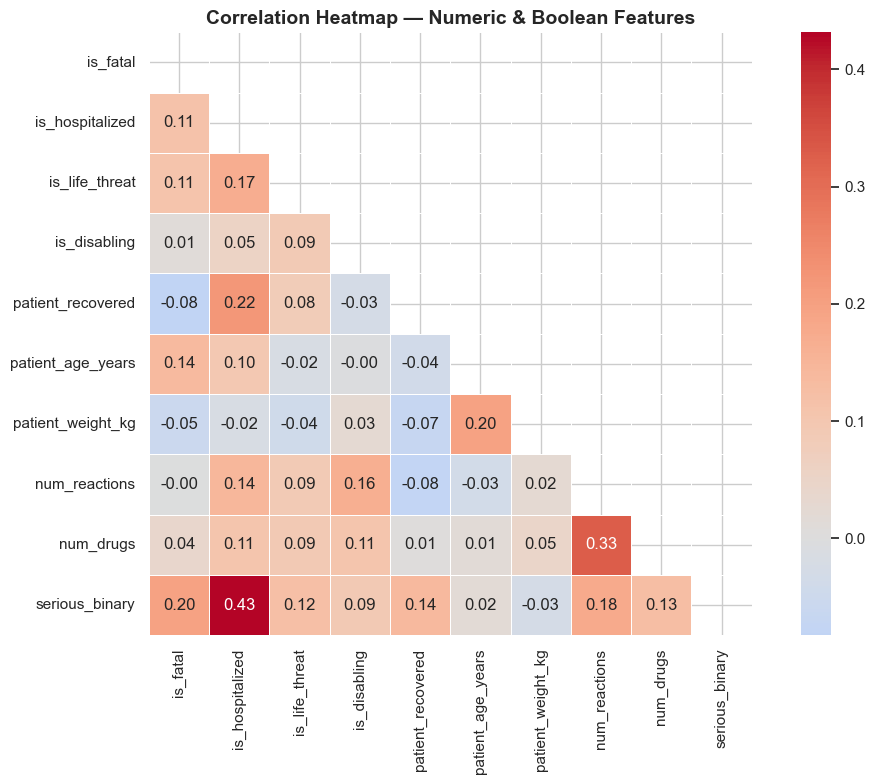

In [48]:
bool_cols = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling', 'patient_recovered']
num_cols  = ['patient_age_years', 'patient_weight_kg', 'num_reactions', 'num_drugs']

corr_df = df[bool_cols + num_cols + ['serious_binary']].copy()
# Convert bool cols to int if needed
for col in bool_cols:
    corr_df[col] = corr_df[col].astype(float)

corr_matrix = corr_df.corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numeric & Boolean Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

---
## 13. EDA Summary & Key Findings

Write your observations here after running all cells. Use this section in your README.

**Suggested prompts:**
- What % of events are classified as serious?
- Which age group has the highest serious event rate?
- Which drug administration route is most common?
- Does polypharmacy (taking more drugs) increase seriousness?
- Are there any surprising correlations in the heatmap?

---

**✅ Next Step:** Open `02_preprocessing.ipynb` to clean, encode, and prepare features for modeling.